## Analysis of EuRepoC Reported Cyber Incidents 
# Goal is to use NLP and machine learning to predict target countries of cyber attacks
Dataset: eurepoc_dyadic_dataset_0_1.csv

Which latent types of cyber operations emerge from incident descriptions, and how do these topics differ in intensity, impact, and political response? Are geopolitical cyber-conflict topics (Russia-Ukraine, Iran-Israel, China/APT, North Korea) associated with systematically different intensity levels and political responses?

1. Clean attack descriptions
2. Generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Topic discovery
5. Relationship with weighted intensity


Old Idea 1: Map the evolution of state-sponsord cyber operations from 2000-2024 using BERTopic and transformer embeddings.

1. Clean attack descriptions
2. generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Extract countries and organizations (spaCy)
5. Track topics over time
6. Build attack-type classifier
7. Visualize geopolitical networks

Old Idea 2: Predict receiver country based on initiating country, operation type, source disclosure (reported by whom), data theft, disruption, hijacking, ransomware, doxxing, physical effects (spatial, temporal), weighted cyber intensity (higher weightings for politically motivated attacks), impact indicator (sum of individual impact scores), political impact, intelligence impact, economic impact, number political responses, number legal responses

In [126]:
import pandas as pd
import html
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

pio.renderers.default = "browser"

In [97]:
# Read in data 
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_full = pd.read_csv(url)

print(dyadic_data_full.shape)
print(dyadic_data_full.head())

(4296, 57)
   dyad_id initiator_country initiator_alpha_2 receiver_country  \
0        0       Afghanistan                AF      Afghanistan   
1        1       Afghanistan                AF         Pakistan   
2        1       Afghanistan                AF         Pakistan   
3        2           Algeria                DZ          Algeria   
4        2           Algeria                DZ          Algeria   

  receiver_country_alpha_2_code  incident_id  \
0                            AF         4278   
1                            PK          488   
2                            PK          499   
3                            DZ          525   
4                            DZ         1183   

                                                name  \
0  TalibLeaks Hacked and Leaked Documents from Ta...   
1               Afghan Cyber Army attack on Pakistan   
2       Afghan Cyber Army attack on Pakistan Part II   
3            Over-X vs. Algerian ministry of housing   
4               N

In [98]:
vars_to_check = [
    "impact_indicator_score",
    "weighted_intensity",
    "unweighted_intensity",
    "economic_impact",
    "functional_impact",
    "intelligence_impact"
]

for var in vars_to_check:
    print(f"\n{'='*60}")
    print(f"Value counts for: {var}")
    print(f"{'='*60}")
    print(dyadic_data_full[var].value_counts(dropna=False).sort_index())


Value counts for: impact_indicator_score
impact_indicator_score
0     2002
1       10
2       11
3       25
4       47
5      384
6      609
7      467
8      255
9      279
10     102
11      59
12      18
13      20
14       6
15       2
Name: count, dtype: int64

Value counts for: weighted_intensity
weighted_intensity
0      125
1     1284
2      594
3     1294
4      751
5      146
6       91
7        1
8        4
9        5
11       1
Name: count, dtype: int64

Value counts for: unweighted_intensity
unweighted_intensity
0     103
1    1296
2     600
3    1288
4     793
5     147
6      68
7       1
Name: count, dtype: int64

Value counts for: economic_impact
economic_impact
=< 10 Mio               56
> 10 Mio - 100 Mio      31
> 100 Mio - 1 bn         5
Not available         4204
Name: count, dtype: int64

Value counts for: functional_impact
functional_impact
Day (< 24h)                           273
Days (< 7 days)                       405
Months                                

In [99]:
# Isolate columns of interest
drop_vars = ["added_to_db","updated_at","attribution_id",\
    "initiator_alpha_2","receiver_country_alpha_2_code",
    "Data theft","Data theft & Doxing","Disruption",
    "Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]

attack_labels = ["Data theft","Data theft & Doxing", \
    "Disruption","Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]
attack_data = dyadic_data_full[["incident_id"] + attack_labels].copy()

dyadic_data = dyadic_data_full.drop(columns=drop_vars,\
    errors="ignore")

print(f"Original shape: {dyadic_data_full.shape}")
print(f"New shape: {dyadic_data.shape}")

print("\nRemaining columns:")
print(dyadic_data.columns.tolist())


Original shape: (4296, 57)
New shape: (4296, 45)

Remaining columns:
['dyad_id', 'initiator_country', 'receiver_country', 'incident_id', 'name', 'description', 'start_date', 'end_date', 'source_disclosure', 'operation_type', 'impact_indicator_score', 'impact_indicator_label', 'unweighted_intensity', 'weighted_intensity', 'number_attributions', 'number_political_responses', 'number_legal_responses', 'casualties', 'initiator_name', 'initiator_category', 'initiator_subcategory', 'receiver_id', 'receiver_name', 'receiver_category', 'receiver_subcategory', 'receiver_regions', 'offline_conflict_issue', 'offline_conflict_name', 'offline_conflict_intensity', 'offline_conflict_intensity_subcode', 'cyber_conflict_issue', 'physical_effects_spatial', 'physical_effects_temporal', 'target_multiplier', 'functional_impact', 'intelligence_impact', 'economic_impact', 'economic_impact_value', 'economic_impact_currency', 'affected_entities', 'affected_entities_value', 'affected_eu_countries', 'affected_eu

In [100]:
# Check for missing values in descriptions
print(dyadic_data["description"].isnull().sum())
print(dyadic_data[dyadic_data["description"]==""])

0
Empty DataFrame
Columns: [dyad_id, initiator_country, receiver_country, incident_id, name, description, start_date, end_date, source_disclosure, operation_type, impact_indicator_score, impact_indicator_label, unweighted_intensity, weighted_intensity, number_attributions, number_political_responses, number_legal_responses, casualties, initiator_name, initiator_category, initiator_subcategory, receiver_id, receiver_name, receiver_category, receiver_subcategory, receiver_regions, offline_conflict_issue, offline_conflict_name, offline_conflict_intensity, offline_conflict_intensity_subcode, cyber_conflict_issue, physical_effects_spatial, physical_effects_temporal, target_multiplier, functional_impact, intelligence_impact, economic_impact, economic_impact_value, economic_impact_currency, affected_entities, affected_entities_value, affected_eu_countries, affected_eu_countries_value, affected_third_countries, affected_third_countries_value]
Index: []

[0 rows x 45 columns]


In [101]:
# Incident-level dataset for NLP
# Descriptions can be duplicated because of the dyadic nature of the dataset. 
# One incident may span several rows if it affected several countries. 
incident_text_data = (
    dyadic_data
    .drop_duplicates(subset=["incident_id"])
    .copy()
)
print(incident_text_data.head())


   dyad_id initiator_country receiver_country  incident_id  \
0        0       Afghanistan      Afghanistan         4278   
1        1       Afghanistan         Pakistan          488   
2        1       Afghanistan         Pakistan          499   
3        2           Algeria          Algeria          525   
4        2           Algeria          Algeria         1183   

                                                name  \
0  TalibLeaks Hacked and Leaked Documents from Ta...   
1               Afghan Cyber Army attack on Pakistan   
2       Afghan Cyber Army attack on Pakistan Part II   
3            Over-X vs. Algerian ministry of housing   
4               North African Fox Espionage campaign   

                                         description           start_date  \
0  On 7 February 2025, a group of hackers, callin...  2024-01-01 00:00:00   
1  Afghan hackers deface six Pakistani government...  2013-07-11 00:00:00   
2  Afghan hackers hack the webpage of the Pakista...  2013-

In [102]:
# Clean description
incident_text_data["description"] = (
    incident_text_data["description"] 
    .fillna("")
    .astype(str)
    .apply(html.unescape)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [103]:
# Missing descriptions
print(incident_text_data["description"].isna().sum())

# Empty descriptions
print((incident_text_data["description"] == "").sum())

# Length distribution
incident_text_data["n_words"] = (
    incident_text_data["description"]
    .str.split()
    .str.len()
)

print(incident_text_data["n_words"].describe())

incident_text_data.loc[
    incident_text_data["n_words"] < 5,
    ["incident_id", "description"]
].head(20)


0
0
count    2957.000000
mean       80.144065
std        69.850175
min         3.000000
25%        29.000000
50%        65.000000
75%       112.000000
max       975.000000
Name: n_words, dtype: float64


,incident_id,description
1366,361,Taliban website hacked
2433,370,Israeli Government Site Hacked
4058,358,The Unknowns' hack NASA


In [104]:
# Check how many short descriptions I'd lose if I filtered them out
print((incident_text_data["n_words"] < 5).sum())
print((incident_text_data["n_words"] < 10).sum())

3
105


In [105]:
# Filter out descriptions with less than five words
incident_text_data = incident_text_data[incident_text_data["n_words"] > 5]

In [106]:
# Sentence embeddings with BERT
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    incident_text_data["description"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 92/92 [00:02<00:00, 44.06it/s]


In [107]:
print(embeddings)

[[-0.13852212  0.04736803  0.00694796 ... -0.1016911  -0.00720175
   0.0073006 ]
 [-0.08837775 -0.0068462   0.0352748  ... -0.02053824  0.08904102
  -0.01114137]
 [-0.05292993  0.02389424 -0.02115013 ... -0.03376359  0.02942775
  -0.04175749]
 ...
 [-0.08312131  0.09502239 -0.02489242 ... -0.08411338 -0.04242385
  -0.00853652]
 [-0.04408563 -0.01750997 -0.0210795  ... -0.03124391 -0.0302697
  -0.06215569]
 [ 0.02379923  0.06802905  0.04300077 ... -0.10118835 -0.06035246
   0.04033769]]


In [108]:
# Get rid of stopwords, BERT wasn't using them effectively
vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)
)

# BERTopic analysis 
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    min_topic_size=20,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(
    incident_text_data["description"],
    embeddings
)

2026-08-17 15:11:54,114 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-17 15:11:57,333 - BERTopic - Dimensionality - Completed ✓
2026-08-17 15:11:57,333 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-17 15:11:57,393 - BERTopic - Cluster - Completed ✓
2026-08-17 15:11:57,394 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-17 15:11:57,494 - BERTopic - Representation - Completed ✓


In [109]:
# Examine topics
topic_info = topic_model.get_topic_info()
#print(topic_info.head())

topic_info[["Topic", "Count", "Representation"]]\
    .style.set_table_attributes(
        'style="display:block;max-height:500px;overflow:auto;"'
    )

,Topic,Count,Representation
0,-1,790,"['group', 'government', 'russian', 'hackers', 'campaign', 'cyber', 'website', 'anonymous', 'attack', 'websites']"
1,0,963,"['data', 'ransomware', 'information', '2024', 'incident', 'systems', 'attack', '2023', 'company', 'unknown']"
2,1,269,"['chinese', 'threat', 'group', 'government', 'malware', 'apt', 'security', 'china', 'vulnerability', 'statesponsored']"
3,2,188,"['ddos', 'attack', 'ddos attack', 'websites', 'attacks', 'website', 'ddos attacks', 'prorussian', 'hacktivist', 'hacktivist group']"
4,3,104,"['russian', 'ukrainian', '2022', 'data', 'ukraine', 'ministry', 'intelligence', 'group', 'cyber', 'ministry defense']"
5,4,88,"['iranian', 'iran', 'israeli', 'group', 'israel', 'hacking', 'hacking group', 'statesponsored', 'report', '2023']"
6,5,71,"['israeli', 'websites', 'israel', 'website', 'defaced', 'hacked', 'ministry', 'anonymous', 'army', 'hackers']"
7,6,69,"['pakistani', 'indian', 'pakistan', 'websites', 'website', 'hacked', 'hackers', 'deface', 'government', 'defaced']"
8,7,68,"['million', 'exchange', 'platform', 'assets', 'protocol', 'lazarus', 'theft', 'unknown', 'stolen', 'worth']"
9,8,65,"['ukrainian', 'russian', 'malware', 'microsoft', 'campaign', 'threat', 'used', 'report', 'russian statesponsored', 'group']"


In [110]:
# Add topic info to deduplicated dataset
incident_text_data["topic"] = topics
incident_text_data["topic_prob"] = probs.max(axis=1)

# Create a look-up table
topic_lookup = incident_text_data[
    ["incident_id", "topic"]
].copy()

# Create interpretable topic labels
topic_info = topic_model.get_topic_info()

topic_labels = (
    topic_info[["Topic", "Representation"]]
    .copy()
)

topic_labels["topic_label"] = (
    topic_labels["Representation"]
    .apply(lambda x: ", ".join(x[:5]))
)

# Merge topics onto dyadic data
dyadic_data = dyadic_data.merge(
    topic_lookup,
    on="incident_id",
    how="left"
)

dyadic_data = dyadic_data.merge(
    topic_labels[["Topic", "topic_label"]],
    left_on="topic",
    right_on="Topic",
    how="left"
)

print(dyadic_data["topic"].isna().sum())
print(dyadic_data["topic"].value_counts().head())


15
topic
-1.0    1258
 0.0    1041
 1.0     702
 2.0     197
 4.0     187
Name: count, dtype: int64


In [111]:
print(
    dyadic_data[
        ["topic", "topic_label"]
    ].drop_duplicates()
    .sort_values("topic")
)

      topic                                        topic_label
0      -1.0      group, government, russian, hackers, campaign
11      0.0      data, ransomware, information, 2024, incident
101     1.0        chinese, threat, group, government, malware
624     2.0       ddos, attack, ddos attack, websites, attacks
57      3.0            russian, ukrainian, 2022, data, ukraine
322     4.0              iranian, iran, israeli, group, israel
5       5.0        israeli, websites, israel, website, defaced
1       6.0     pakistani, indian, pakistan, websites, website
1119    7.0      million, exchange, platform, assets, protocol
61      8.0   ukrainian, russian, malware, microsoft, campaign
362     9.0   korean, north, south, south korean, north korean
34     10.0  anonymous, protest, government websites, websi...
18     11.0           leaked, hackers, hacked, email, officers
10     12.0     websites, website, anonymous, defaced, defaces
3      13.0    turkish, azerbaijan, defaced, website, m

In [112]:
# Remove outliers
dyadic_data = dyadic_data[
    dyadic_data["topic"] != -1
].copy()

In [113]:
# Topic vs intensity
dyadic_data.groupby("topic_label")["weighted_intensity"]\
    .mean()\
    .sort_values(ascending=False)

topic_label
data, ransomware, information, 2024, incident                    3.399616
spyware, phones, international, human rights, phone              3.387097
kaspersky, malware, apt, using, entities                         2.887640
russian, ukrainian, 2022, data, ukraine                          2.649123
ukrainian, russian, malware, microsoft, campaign                 2.621622
iranian, iran, israeli, group, israel                            2.486631
chinese, threat, group, government, malware                      2.447293
lazarus, korean, north korean, north, korean statesponsored      2.298246
korean, north, south, south korean, north korean                 2.189189
million, exchange, platform, assets, protocol                    1.957143
leaked, hackers, hacked, email, officers                         1.500000
pakistani, indian, pakistan, websites, website                   1.493506
israeli, websites, israel, website, defaced                      1.475000
turkish, azerbaijan, defac

In [114]:
# Topic vs political responses
dyadic_data.groupby("topic_label")["number_political_responses"]\
    .mean()\
    .sort_values(ascending=False)

topic_label
ukrainian, russian, malware, microsoft, campaign                 0.648649
spyware, phones, international, human rights, phone              0.322581
ddos, attack, ddos attack, websites, attacks                     0.309645
data, ransomware, information, 2024, incident                    0.171950
korean, north, south, south korean, north korean                 0.121622
iranian, iran, israeli, group, israel                            0.074866
russian, ukrainian, 2022, data, ukraine                          0.070175
million, exchange, platform, assets, protocol                    0.057143
websites, website, anonymous, defaced, defaces                   0.054054
chinese, threat, group, government, malware                      0.044160
israeli, websites, israel, website, defaced                      0.025000
lazarus, korean, north korean, north, korean statesponsored      0.017544
pakistani, indian, pakistan, websites, website                   0.000000
leaked, hackers, hacked, e

In [115]:
# Most common receiver countries by topic
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic"]
)

topic,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
receiver_country,,,,,,,,,,,,,,,,,
Afghanistan,0,7,0,0,3,0,3,0,4,0,0,0,0,0,2,0,0
Africa,0,3,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0
Albania,0,1,0,0,2,0,0,0,0,0,0,0,0,1,0,0,1
Algeria,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
Angola,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,2,26,0,0,0,0,0,0,1,1,0,0,0,0,2,0,0
"Virgin Islands, British",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Western Europe,0,3,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0


## Visualizations

In [116]:
# What cyber conflict themes dominate the dataset?
topic_counts = (
    dyadic_data["topic_label"]
    .value_counts()
    .reset_index()
)

topic_counts.columns = ["topic", "count"]

fig = px.treemap(
    topic_counts,
    path=["topic"],
    values="count",
    title="Distribution of Cyber Conflict Topics"
)

fig.show()

fig.write_html("topic_treemap.html")

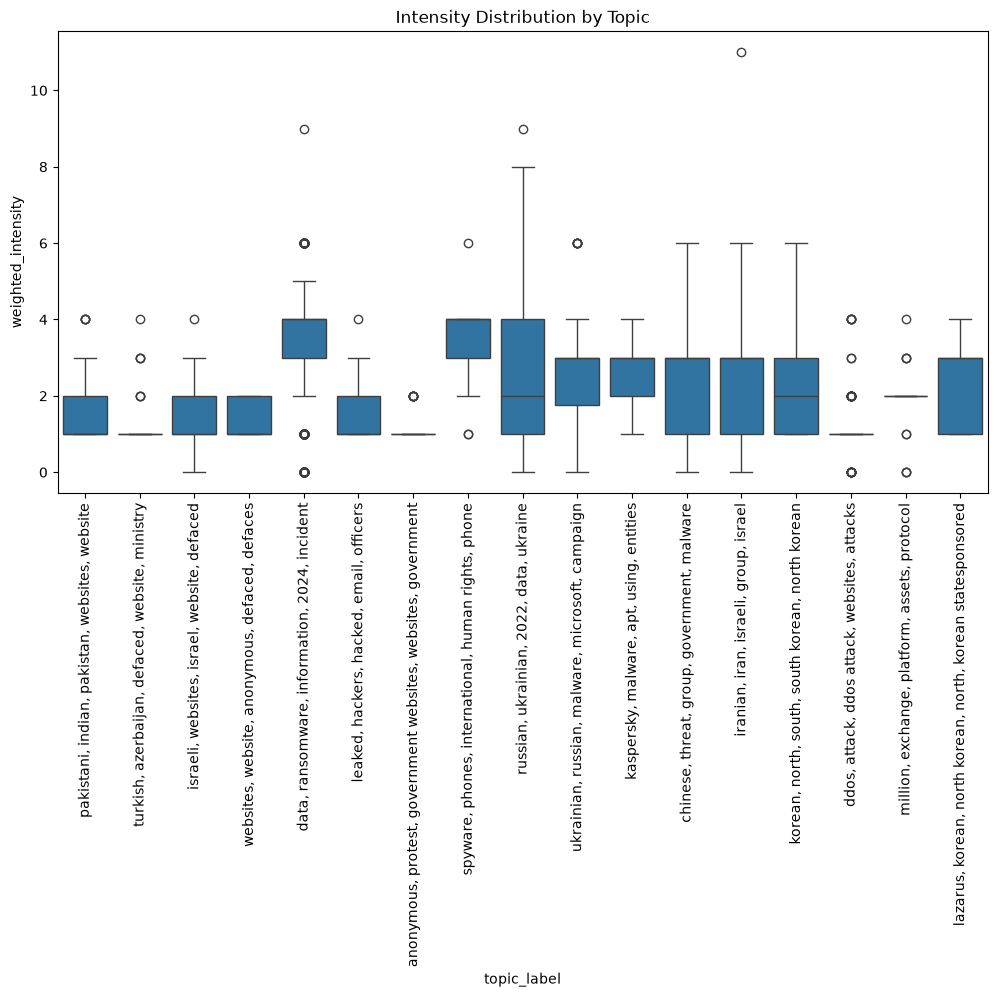

In [117]:
# What cyber conflicts are most intense?
plt.figure(figsize=(12,6))

sns.boxplot(
    data=dyadic_data,
    x="topic_label",
    y="weighted_intensity"
)

plt.xticks(rotation=90)
plt.title("Intensity Distribution by Topic")
plt.show()

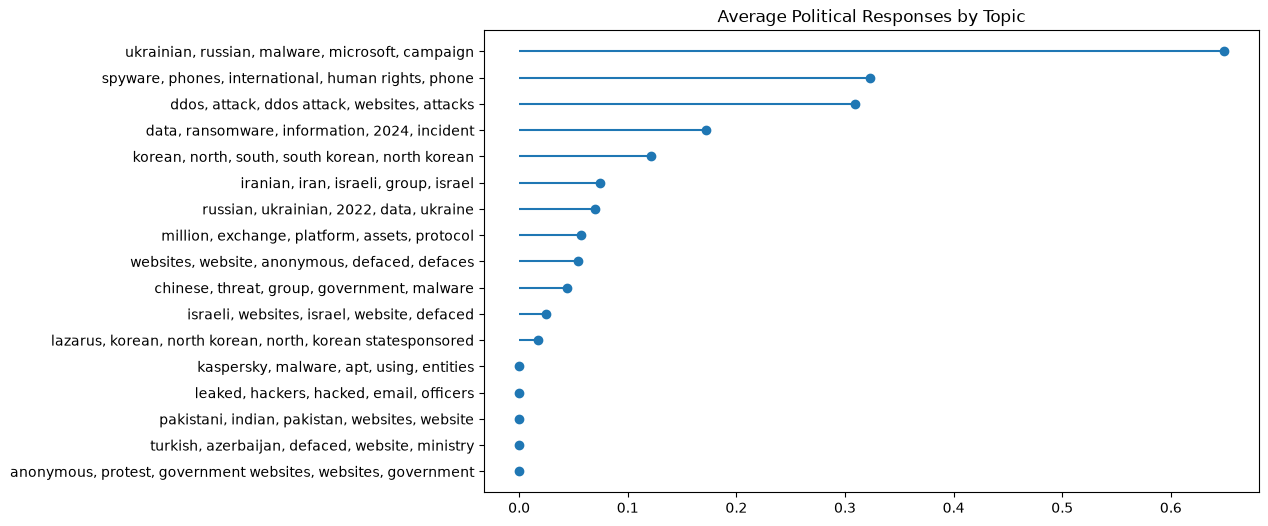

In [118]:
# What cyber conflicts trigger political reactions?
responses = (
    dyadic_data.groupby("topic_label")
    ["number_political_responses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=responses.index,
    xmin=0,
    xmax=responses.values
)

plt.plot(
    responses.values,
    responses.index,
    "o"
)

plt.title("Average Political Responses by Topic")
plt.show()

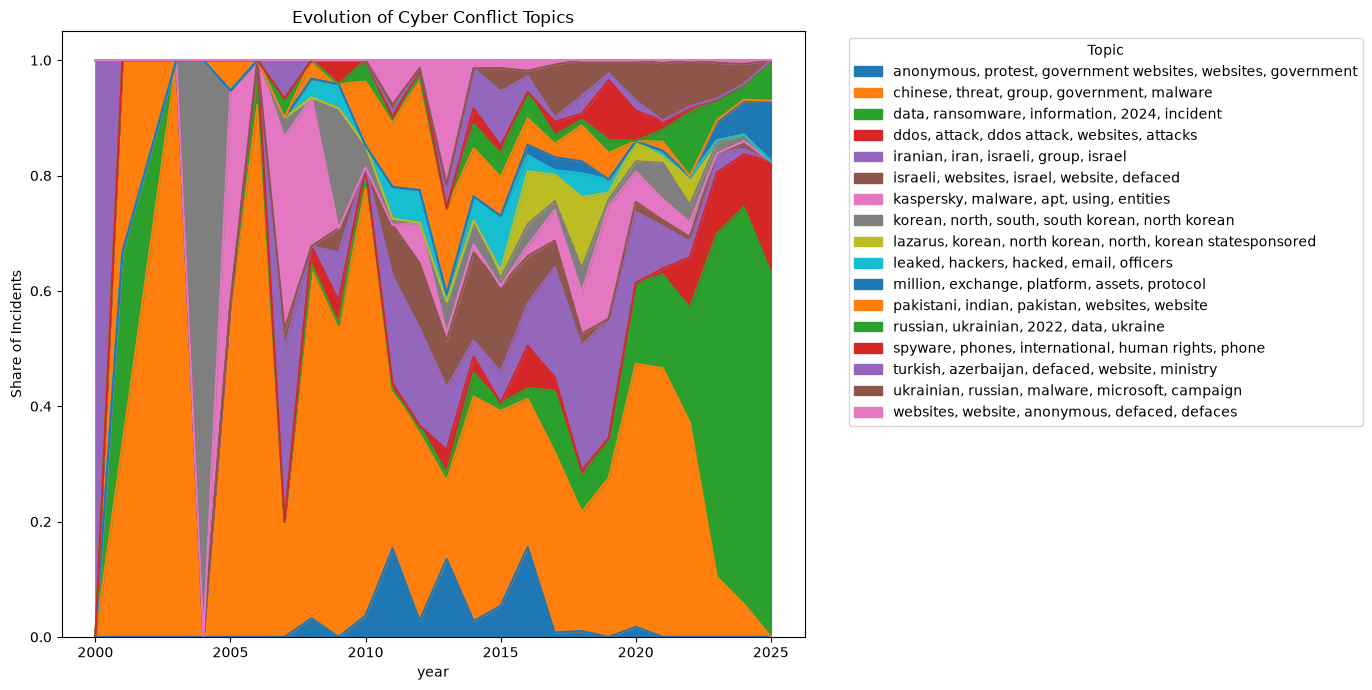

In [119]:
# How has the nature of cyber conflict changed over time?
dyadic_data["year"] = pd.to_datetime(
    dyadic_data["start_date"],
    errors="coerce"   # invalid dates become NaT
).dt.year

topic_year = pd.crosstab(
    dyadic_data["year"],
    dyadic_data["topic_label"],
    normalize="index"
)

fig, ax = plt.subplots(figsize=(14, 7))

topic_year.plot.area(ax=ax)

ax.set_title("Evolution of Cyber Conflict Topics")
ax.set_ylabel("Share of Incidents")

ax.legend(
    title="Topic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


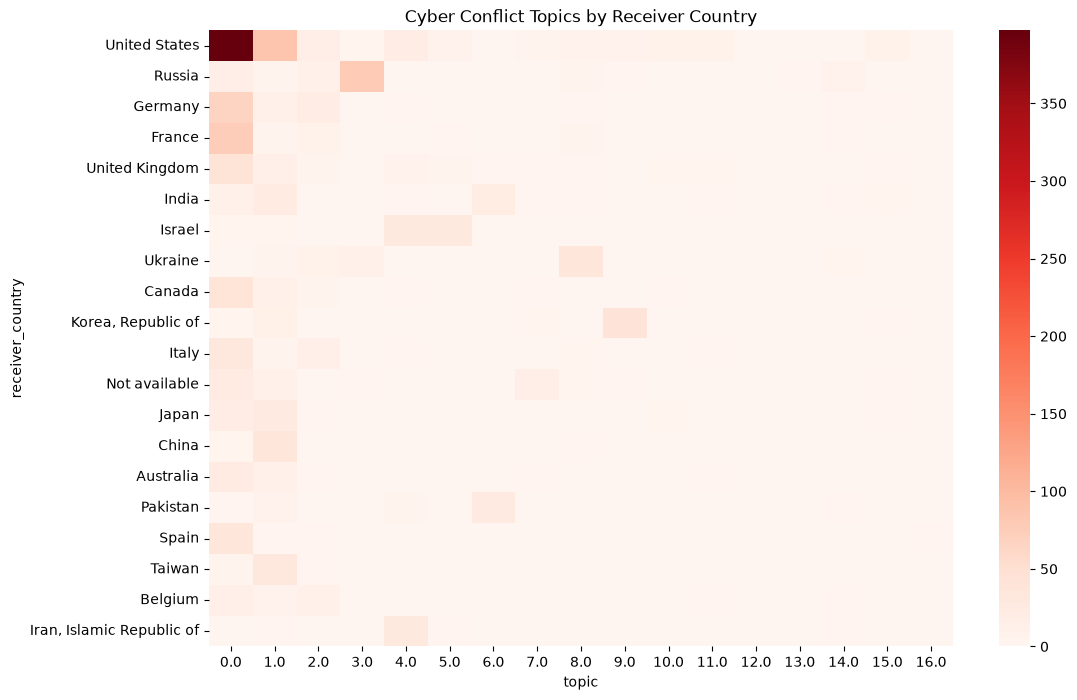

In [120]:
# Which countries are disproportinately affected by certain types of cyber attacks?
country_topic = pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic"]
)

top_countries = (
    country_topic.sum(axis=1)
    .nlargest(20)
    .index
)

plt.figure(figsize=(12,8))

sns.heatmap(
    country_topic.loc[top_countries],
    cmap="Reds"
)

plt.title("Cyber Conflict Topics by Receiver Country")
plt.show()

In [121]:
# Filters for sankey visual
top_initiators = (
    dyadic_data["initiator_country"]
    .value_counts()
    .head(10)
    .index
)

top_receivers = (
    dyadic_data["receiver_country"]
    .value_counts()
    .head(10)
    .index
)

sankey_data = dyadic_data[
    dyadic_data["initiator_country"].isin(top_initiators)
    &
    dyadic_data["receiver_country"].isin(top_receivers)
].copy()

In [122]:
# Shorten topic labels
sankey_data["short_topic"] = (
    sankey_data["topic_label"]
    .str.split(",")
    .str[:3]
    .str.join(", ")
)

In [123]:
# Create flows
# Initiator -> Topic
flow1 = (
    sankey_data
    .groupby(
        ["initiator_country", "short_topic"]
    )
    .size()
    .reset_index(name="value")
)

# Topic -> Reciever
flow2 = (
    sankey_data
    .groupby(
        ["short_topic", "receiver_country"]
    )
    .size()
    .reset_index(name="value")
)

In [124]:
# Build node list
nodes = list(
    pd.concat([
        flow1["initiator_country"],
        flow1["short_topic"],
        flow2["receiver_country"]
    ]).unique()
)

node_dict = {
    node: i
    for i, node in enumerate(nodes)
}

In [125]:
# Build link table
source = []
target = []
value = []

# Initiator -> Topic
for _, row in flow1.iterrows():
    source.append(
        node_dict[row["initiator_country"]]
    )
    target.append(
        node_dict[row["short_topic"]]
    )
    value.append(row["value"])

# Topic -> Receiver
for _, row in flow2.iterrows():
    source.append(
        node_dict[row["short_topic"]]
    )
    target.append(
        node_dict[row["receiver_country"]]
    )
    value.append(row["value"])

In [127]:
fig = go.Figure(
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            label=nodes
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title="Cyber Conflict Flows: Initiator → Topic → Receiver",
    font_size=10
)

fig.show()